In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(color_codes=True)
from sklearn .preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path='/content/drive/MyDrive/ChronicKidneyDisease.csv'
df=pd.read_csv(file_path)
df

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,80.0,1.020,0.0,0.0,1.0,49.0,0.5,150.00,4.90,15.7,6700.0,4.90,0.0,0
396,70.0,1.025,0.0,0.0,1.0,31.0,1.2,141.00,3.50,16.5,7800.0,6.20,0.0,0
397,80.0,1.020,0.0,0.0,1.0,26.0,0.6,137.00,4.40,15.8,6600.0,5.40,0.0,0
398,60.0,1.025,0.0,0.0,1.0,50.0,1.0,135.00,4.90,14.2,7200.0,5.90,0.0,0


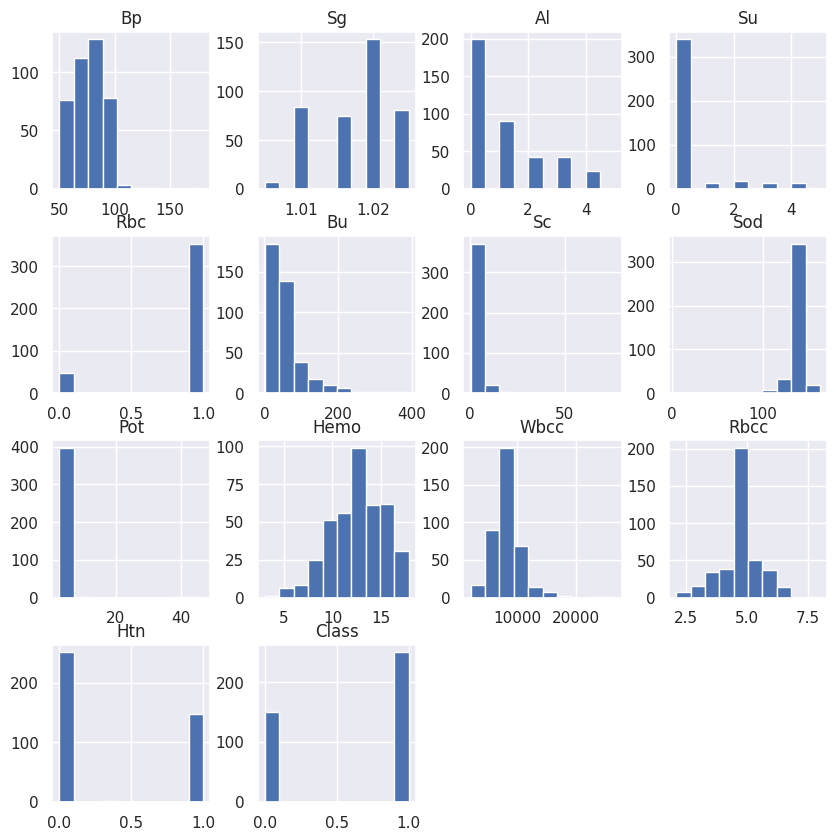

In [4]:
df.hist(figsize=(10,10))
plt.show()

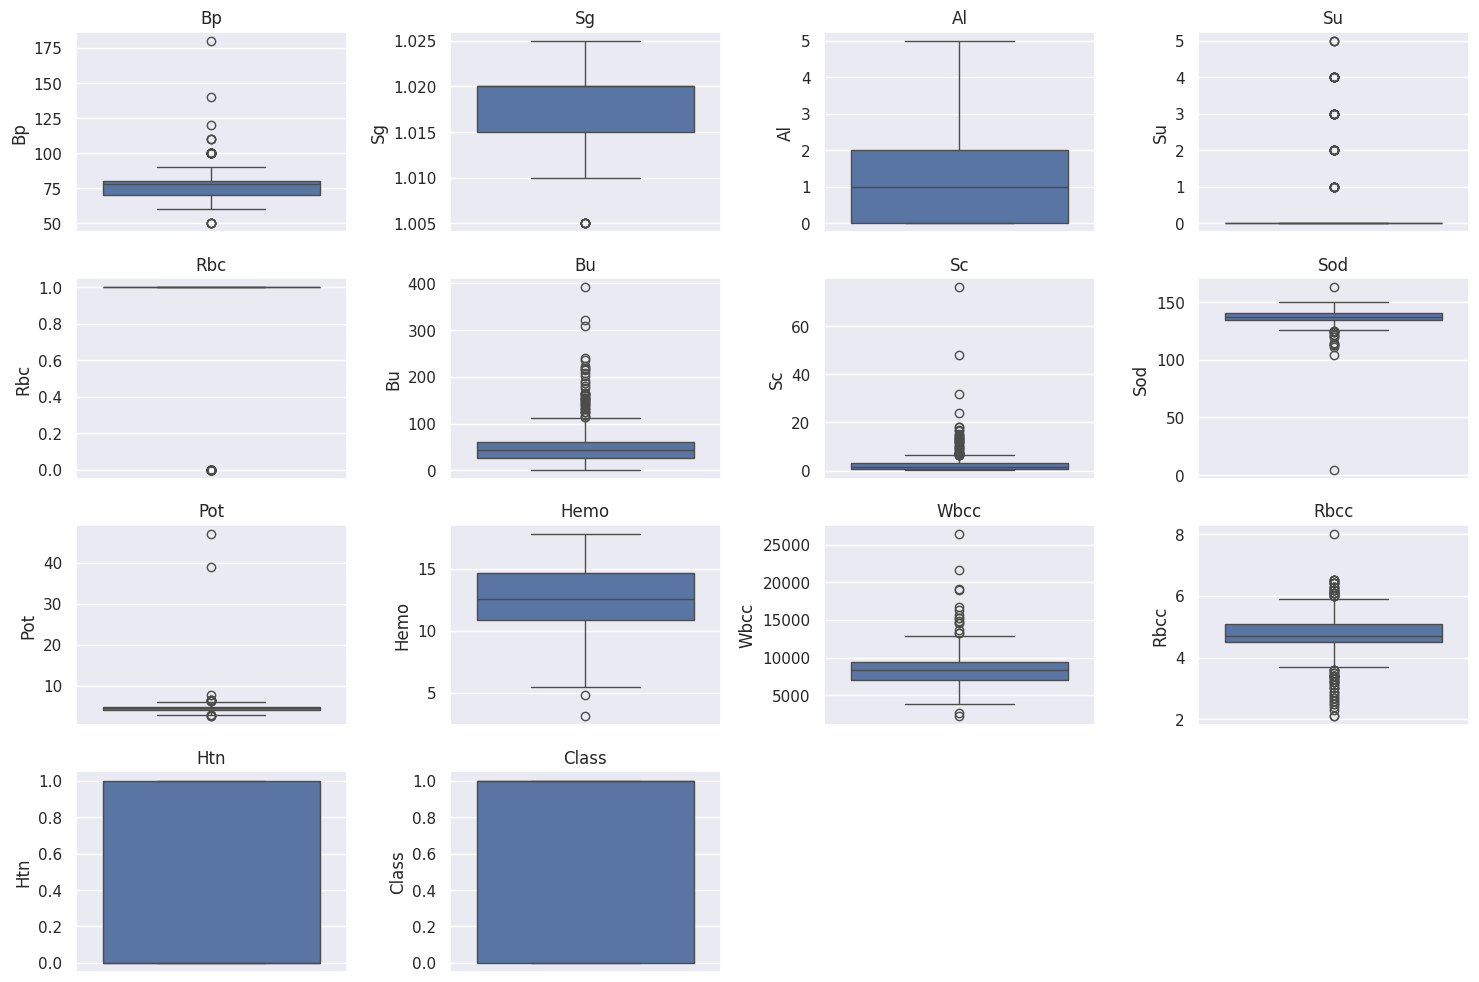

In [5]:
numeric_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

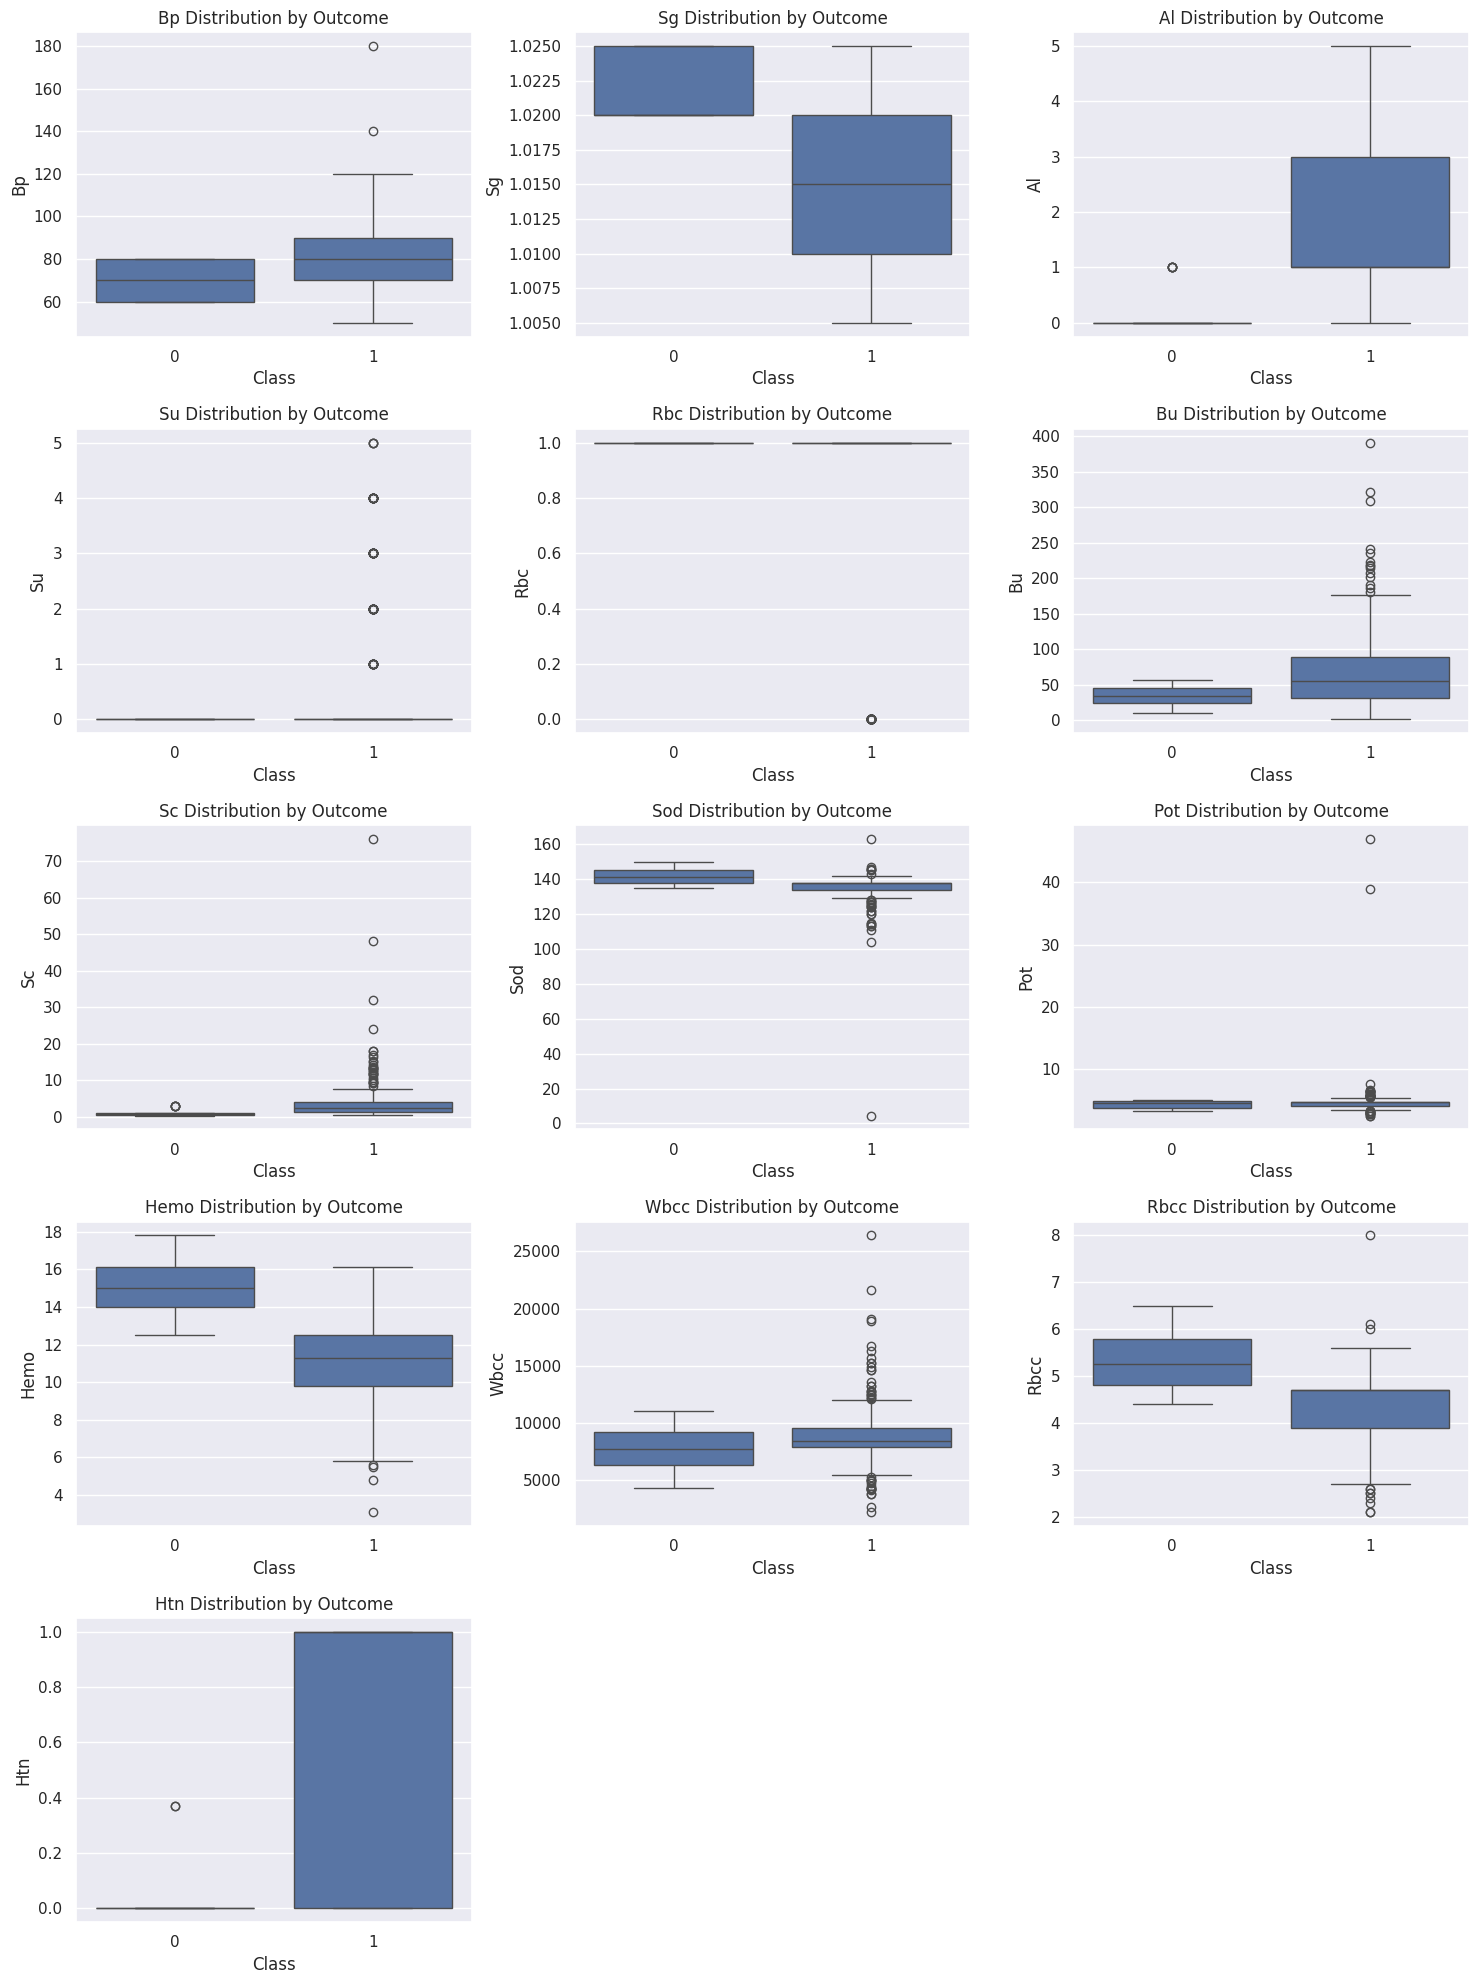

In [7]:
numerical_features = df.columns.drop('Class')

plt.figure(figsize=(15, 20))
for i, feature in enumerate(numerical_features):
    plt.subplot(len(numerical_features) // 3 + 1, 3, i + 1)
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f'{feature} Distribution by Outcome')
plt.tight_layout()
plt.show()

In [ ]:
x = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)    #normalized
x_test=scaler.fit_transform(x_test)
Ir=LogisticRegression()
Ir.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=Ir.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix
print("logistic regression accuracy")
accuracy_score(y_test,y_pred)

logistic regression accuracy


0.975

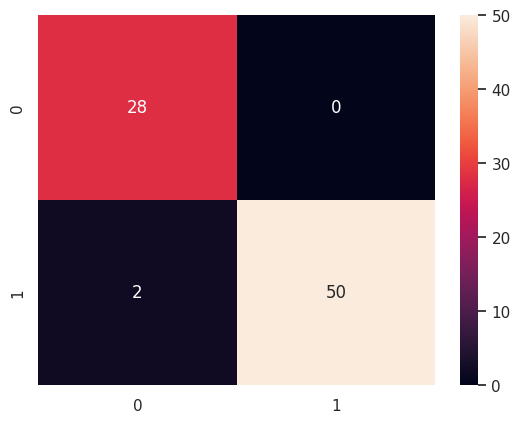

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
print("\n--- Interactive CKD Prediction ---")

while True:
    print("\nPlease enter values for the following features (type 'quit' to exit):")
    try:
        Bp_input = input("Bp (Blood Pressure): ")
        if Bp_input.lower() == 'quit': break
        Sg_input = input("Sg (Specific Gravity): ")
        if Sg_input.lower() == 'quit': break
        Al_input = input("Al (Albumin): ")
        if Al_input.lower() == 'quit': break
        Su_input = input("Su (Sugar): ")
        if Su_input.lower() == 'quit': break
        Rbc_input = input("Rbc (Red Blood Cells): ")
        if Rbc_input.lower() == 'quit': break
        Bu_input = input("Bu (Blood Urea): ")
        if Bu_input.lower() == 'quit': break
        Sc_input = input("Sc (Serum Creatinine): ")
        if Sc_input.lower() == 'quit': break
        Sod_input = input("Sod (Sodium): ")
        if Sod_input.lower() == 'quit': break
        Pot_input = input("Pot (Potassium): ")
        if Pot_input.lower() == 'quit': break
        Hemo_input = input("Hemo (Hemoglobin): ")
        if Hemo_input.lower() == 'quit': break
        Wbcc_input = input("Wbcc (White Blood Cell Count): ")
        if Wbcc_input.lower() == 'quit': break
        Rbcc_input = input("Rbcc (Red Blood Cell Count): ")
        if Rbcc_input.lower() == 'quit': break
        Htn_input = input("Htn (Hypertension): ")
        if Htn_input.lower() == 'quit': break

        prediction_result = predict_ckd(
            Bp=Bp_input, Sg=Sg_input, Al=Al_input, Su=Su_input, Rbc=Rbc_input, Bu=Bu_input,
            Sc=Sc_input, Sod=Sod_input, Pot=Pot_input, Hemo=Hemo_input, Wbcc=Wbcc_input,
            Rbcc=Rbcc_input, Htn=Htn_input
        )
        print(f"\nPrediction: {prediction_result}")

        another_prediction = input("\nMake another prediction? (yes/no): ")
        if another_prediction.lower() != 'yes':
            break

    except EOFError:
        print("\nInput interrupted. Exiting interactive prediction.")
        break
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        break

print("--- Interactive CKD Prediction Ended ---")



--- Interactive CKD Prediction ---

Please enter values for the following features (type 'quit' to exit):
